#📌 Extracción

In [1]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
datos_telecom = pd.read_json('TelecomX_Data.json')
datos_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [3]:
customer = pd.json_normalize(datos_telecom['customer'])
phone = pd.json_normalize(datos_telecom['phone'])
internet = pd.json_normalize(datos_telecom['internet'])
account = pd.json_normalize(datos_telecom['account'])

In [4]:
df_final = pd.concat(
    [datos_telecom[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [6]:
df_final['Charges.Total'].value_counts()

,count
Charges.Total,
20.2,11
,11
19.75,9
19.55,9
19.9,9
...,...
1993.2,1
72.1,1
1237.85,1


In [7]:
df_final['Charges.Total'].str.strip().eq('').sum()

np.int64(11)

In [8]:
df_final['Charges.Total'] = pd.to_numeric(
    df_final['Charges.Total'], errors='coerce'
)

In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [10]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [11]:
# Verificando si esos 11 registros son clientes muy nuevos que aún no han acumulado cargos totales

df_final[df_final['Charges.Total'].isnull()][['tenure','Charges.Monthly','Charges.Total']]

,tenure,Charges.Monthly,Charges.Total
975,0,56.05,NaN
1775,0,20.00,NaN
1955,0,61.90,NaN
2075,0,19.70,NaN
2232,0,20.25,NaN
2308,0,25.35,NaN
2930,0,73.35,NaN
3134,0,25.75,NaN
3203,0,52.55,NaN
4169,0,80.85,NaN


In [12]:
# Eliminar los valores nulos
df_final = df_final.dropna()

In [13]:
df_final['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869
,224


In [14]:
df_final['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.154906
Yes,25.757993
,3.087100


In [15]:
df_final = df_final.dropna(subset=['Churn'])

In [16]:
# Ya con el df limpio ahora para dar mejor sentido a la información, colocaré los nombres de las columnas en español:
df_final = df_final.rename(columns={
    'customerID': 'ID_cliente',
    'Churn': 'abandono',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'pareja',
    'Dependents': 'dependientes',
    'tenure': 'meses_cliente',
    'PhoneService': 'servicio_telefono',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_online',
    'OnlineBackup': 'respaldo_online',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'facturacion_digital',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargo_mensual',
    'Charges.Total': 'cargo_total'
})

In [17]:
df_final.columns

Index(['ID_cliente', 'abandono', 'genero', 'adulto_mayor', 'pareja',
       'dependientes', 'meses_cliente', 'servicio_telefono',
       'lineas_multiples', 'servicio_internet', 'seguridad_online',
       'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'facturacion_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total'],
      dtype='object')

In [18]:
df_final['pareja'].unique()

array(['Yes', 'No'], dtype=object)

In [19]:
df_final['dependientes'].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
# Para efectos de análisis posteriores, tener las columnas: 'adulto_mayor', 'pareja',y 'dependientes' con distinto tipo de datos puede ser un problema

df_final['pareja'] = (df_final['pareja'] == 'Yes').astype(int)
df_final['dependientes'] = (df_final['dependientes'] == 'Yes').astype(int)

In [21]:
df_final.head()

,ID_cliente,abandono,genero,adulto_mayor,pareja,dependientes,meses_cliente,servicio_telefono,lineas_multiples,servicio_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total
0,0002-ORFBO,No,Female,0,1,1,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,0,0,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,0,0,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,1,0,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,1,0,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [22]:
df_final[['adulto_mayor','pareja','dependientes']].value_counts()

adulto_mayor  pareja  dependientes
0             0       0               2800
              1       1               1709
                      0               1197
1             0       0                571
              1       0                518
0             0       1                368
1             1       1                 85
              0       1                  8
Name: count, dtype: int64

#📊 Carga y análisis

In [23]:
# Revelar el patrón de abandono de clientes.

df_final['abandono'].value_counts(normalize=True) * 100

,proportion
abandono,
No,71.154906
Yes,25.757993
,3.087100


In [24]:
# Obtuvimos los datos, pero aparece un tercer valor (3.08%). Esto indica que en la columna 'abandono' todavía hay registros vacíos o con espacios.

df_final['abandono'] = df_final['abandono'].str.strip()
df_final['abandono'] = df_final['abandono'].replace('', pd.NA)
df_final = df_final.dropna(subset=['abandono'])


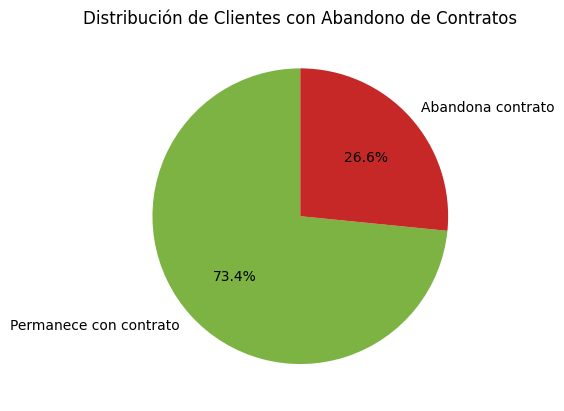

In [25]:
import matplotlib.pyplot as plt

colores = ['#7CB342', '#C62828']
vc = df_final['abandono'].value_counts().sort_index()

vc.plot(
    kind='pie',
    colors=colores,
    labels=['Permanece con contrato', 'Abandona contrato'],
    autopct='%1.1f%%',  # Porcentajes con 1 decimal
    startangle=90  # Rota para mejor vista
)

plt.title('Distribución de Clientes con Abandono de Contratos')
plt.ylabel('')
plt.show()


**Interpretación**

En Telecom X aproximadamente:

3 de cada 4 clientes permanecen y 1 de cada 4 clientes abandona.

Lo que se traduce en un 26.6% de abandono, es considerado alto para empresas de telecomunicaciones, por lo que tiene mucho sentido que la empresa quiera analizar las causas.

Con esto presente, pasemos a realizar el análisis comparativo entre las variables para determinar aquellas que generan mayor impacto en estos resultados.

Realizaré por separado la comparativa de las que considero las principales variables y posterioremente un análisis global general en busca de hallazgos inesperados.

In [26]:
churn_contract = pd.crosstab(
    df_final['tipo_contrato'],
    df_final['abandono'],
    normalize='index'
) * 100

churn_contract['tasa_abandono'] = churn_contract['Yes']

churn_contract = churn_contract.rename(columns={
    'No': 'permanece',
    'Yes': 'abandona'
})


contract_style = churn_contract.style \
       .format({'permanece': '{:,.1f}', 'abandona': '{:,.1f}', 'tasa_abandono': '{:.1f}%'}) \
       .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['tasa_abandono'], color='#FFCDD2')

contract_style

abandono,permanece,abandona,tasa_abandono
tipo_contrato,,,
Month-to-month,57.3,42.7,42.7%
One year,88.7,11.3,11.3%
Two year,97.2,2.8,2.8%


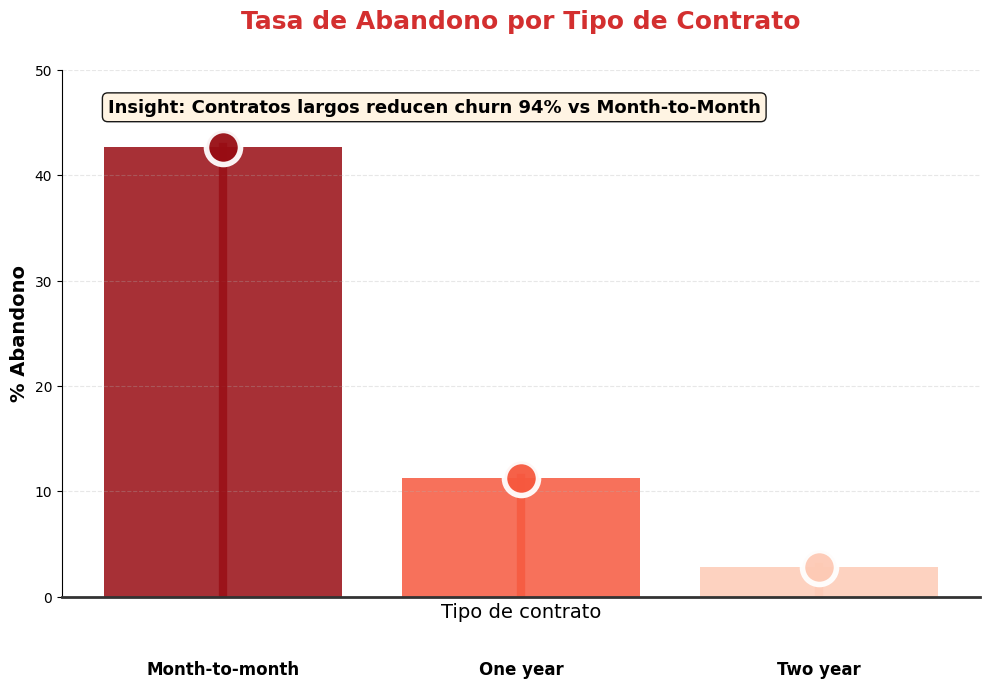

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

colors = plt.cm.Reds(np.linspace(0.9, 0.2, 3))
bars = ax.bar(range(3), churn_contract['tasa_abandono'], color=colors, alpha=0.85)

for i, tasa in enumerate(churn_contract['tasa_abandono']):
    ax.plot([i, i], [0, tasa], color=colors[i], linewidth=6, alpha=0.8)
    ax.scatter(i, tasa, s=600, color=colors[i], alpha=0.95,
               edgecolors='white', linewidth=4, zorder=5)

for i, tasa in enumerate(churn_contract['tasa_abandono']):
    ax.text(i, tasa + 2.5, f'{tasa:.1f}%', ha='center', fontweight='bold', fontsize=14, color='white')
    ax.text(i, -6, churn_contract.index[i], ha='center', va='top',
            fontweight='bold', fontsize=12)

ax.set_ylim(0, 50)
ax.set_title('Tasa de Abandono por Tipo de Contrato', fontsize=18, fontweight='bold', pad=30, color='#D32F2F')
ax.text(0.05, 0.92, 'Insight: Contratos largos reducen churn 94% vs Month-to-Month',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFF3E0', alpha=0.9))
ax.set_ylabel('% Abandono', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de contrato', fontsize=14)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Limpieza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('churn_contrato_potenciado.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Interpretación preliminar:**

Los clientes con contrato Month-to-month tienen mucho mayor probabilidad de cancelar.

Esto ocurre porque:

* No tienen compromiso a largo plazo

* Pueden cancelar fácilmente

* suelen ser clientes nuevos o en prueba

In [28]:
# Análisis comparativo N°2: Antiguedad Vs Abandono. Hipótesis:Los clientes nuevos tienen mayor probabilidad de abandono.

antiguedad = pd.crosstab(df_final['meses_cliente'], df_final['abandono'])
antiguedad

abandono,No,Yes
meses_cliente,,
1,233,380
2,115,123
3,106,94
4,93,83
5,69,64
...,...,...
68,91,9
69,87,8
70,108,11


In [29]:
#La columna 'meses_cliente' tiene demasiados valores y eso hace que el análisis y los gráficos sean difíciles de interpretar.

df_final['grupo_antiguedad'] = pd.cut(
    df_final['meses_cliente'],
    bins=[0,6,12,24,72],
    labels=['0-6 meses','7-12 meses','13-24 meses','24+ meses']
)

In [30]:
tabla_antiguedad = pd.crosstab(
    df_final['grupo_antiguedad'],
    df_final['abandono'],
    normalize='index'
) * 100

tabla_antiguedad = tabla_antiguedad.rename(columns={
    'No': 'permanece',
    'Yes': 'abandona'
})

tabla_antiguedad['tasa_abandono'] = tabla_antiguedad['abandona']

tabla_style = tabla_antiguedad.style \
       .format({'permanece': '{:,.1f}', 'abandona': '{:,.1f}', 'tasa_abandono': '{:.1f}%'}) \
       .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['tasa_abandono'], color='#FFCDD2')

tabla_style

abandono,permanece,abandona,tasa_abandono
grupo_antiguedad,,,
0-6 meses,46.7,53.3,53.3%
7-12 meses,64.1,35.9,35.9%
13-24 meses,71.3,28.7,28.7%
24+ meses,86.0,14.0,14.0%


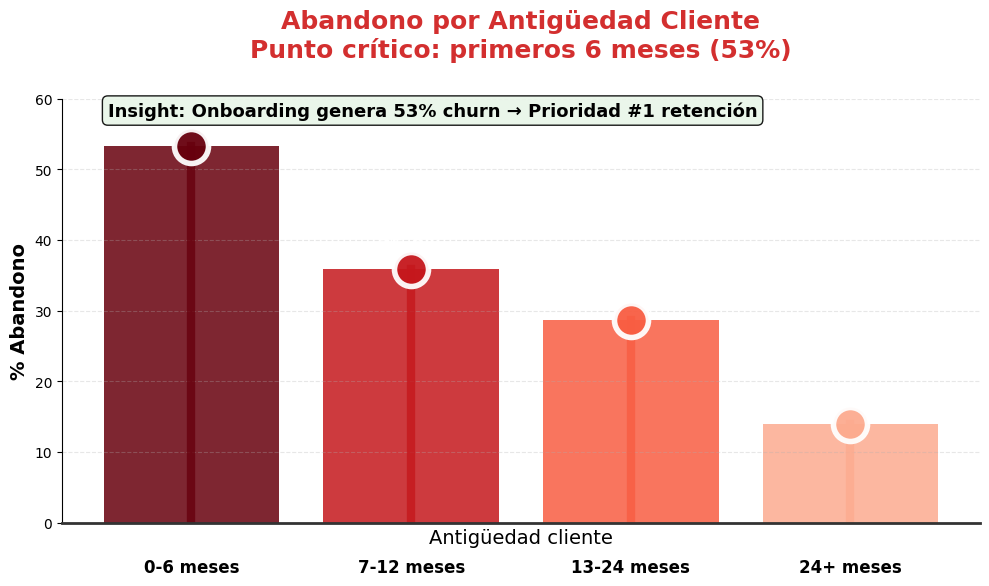

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')


colors = plt.cm.Reds(np.linspace(1, 0.3, 4))
bars = ax.bar(range(4), tabla_antiguedad['abandona'], color=colors, alpha=0.85)


for i, v in enumerate(tabla_antiguedad['abandona']):
    ax.plot([i, i], [0, v], color=colors[i], linewidth=6, alpha=0.8)
    ax.scatter(i, v, s=600, color=colors[i], alpha=0.95,
               edgecolors='white', linewidth=4, zorder=5)


for i, v in enumerate(tabla_antiguedad['abandona']):
    ax.text(i, v + 2.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14, color='white')
    ax.text(i, -5, tabla_antiguedad.index[i], ha='center', va='top',
            fontweight='bold', fontsize=12)

ax.set_ylim(0, 60)
ax.set_title('Abandono por Antigüedad Cliente\nPunto crítico: primeros 6 meses (53%)',
             fontsize=18, fontweight='bold', pad=30, color='#D32F2F')
ax.text(0.05, 0.96, 'Insight: Onboarding genera 53% churn → Prioridad #1 retención',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E8F5E8', alpha=0.9))
ax.set_ylabel('% Abandono', fontsize=14, fontweight='bold')
ax.set_xlabel('Antigüedad cliente', fontsize=14)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Limpieza spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('antiguedad_potenciado.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [32]:
# Análisis comparativo N°3: Cargo mensual vs Abandono. Hipótesis:Precios altos aumentan la probabilidad de abandono.

# Primero crearé rangos de cargo mensual

df_final['grupo_cargo'] = pd.qcut(
    df_final['cargo_mensual'],
    q=4,
    labels=['Bajo','Medio','Alto','Muy alto']
)

In [33]:
# Luego creamos la tabla

cargo_churn = pd.crosstab(
    df_final['grupo_cargo'],
    df_final['abandono'],
    normalize='index'
) * 100

cargo_churn['tasa_abandono'] = cargo_churn['Yes']

cargo_churn = cargo_churn.rename(columns={
    'No': 'permanece',
    'Yes': 'abandona'
})


cargo_style = cargo_churn.style \
       .format({'permanece': '{:,.1f}', 'abandona': '{:,.1f}', 'tasa_abandono': '{:.1f}%'}) \
       .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['tasa_abandono'], color='#FFCDD2')

cargo_style

abandono,permanece,abandona,tasa_abandono
grupo_cargo,,,
Bajo,88.7,11.3,11.3%
Medio,75.4,24.6,24.6%
Alto,62.5,37.5,37.5%
Muy alto,67.1,32.9,32.9%


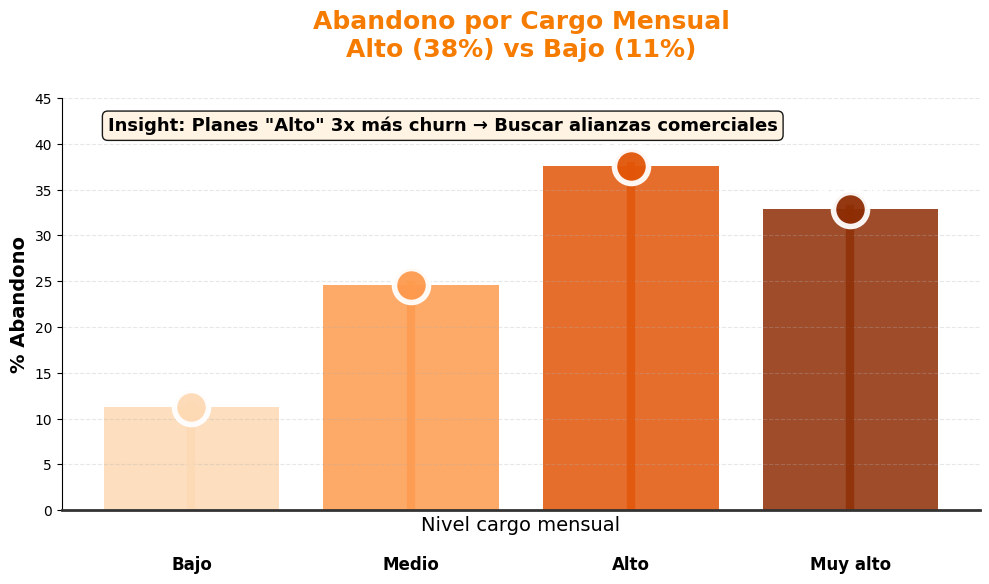

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

colors = plt.cm.Oranges(np.linspace(0.2, 0.95, 4))
bars = ax.bar(range(4), cargo_churn['tasa_abandono'], color=colors, alpha=0.85)


for i, v in enumerate(cargo_churn['tasa_abandono']):
    ax.plot([i, i], [0, v], color=colors[i], linewidth=6, alpha=0.8)
    ax.scatter(i, v, s=600, color=colors[i], alpha=0.95,
               edgecolors='white', linewidth=4, zorder=5)


for i, v in enumerate(cargo_churn['tasa_abandono']):
    ax.text(i, v + 1.8, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=14, color='white')
    ax.text(i, -5, cargo_churn.index[i], ha='center', va='top',
            fontweight='bold', fontsize=12)

ax.set_ylim(0, 45)
ax.set_title('Abandono por Cargo Mensual\nAlto (38%) vs Bajo (11%)',
             fontsize=18, fontweight='bold', pad=30, color='#F57C00')
ax.text(0.05, 0.92, 'Insight: Planes "Alto" 3x más churn → Buscar alianzas comerciales',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFF3E0', alpha=0.9))
ax.set_ylabel('% Abandono', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel cargo mensual', fontsize=14)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3, linestyle='--')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('cargo_churn_potenciado.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [35]:
# Análisis comparativo N°4: Método de pago vs Abandono. Hipótesis:Los clientes con métodos de pago manuales o menos automatizados tienen mayor probabilidad de abandonar el servicio.


metodo_pago_churn = pd.crosstab(
    df_final['metodo_pago'],
    df_final['abandono'],
    normalize='index'
) * 100

metodo_pago_churn['tasa_abandono'] = metodo_pago_churn['Yes']

metodo_pago_churn = metodo_pago_churn.rename(columns={
    'No': 'permanece',
    'Yes': 'abandona'
})


metodo_style = metodo_pago_churn.style \
       .format({'permanece': '{:,.1f}', 'abandona': '{:,.1f}', 'tasa_abandono': '{:.1f}%'}) \
       .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['tasa_abandono'], color='#FFCDD2')

metodo_style

abandono,permanece,abandona,tasa_abandono
metodo_pago,,,
Bank transfer (automatic),83.3,16.7,16.7%
Credit card (automatic),84.7,15.3,15.3%
Electronic check,54.7,45.3,45.3%
Mailed check,80.8,19.2,19.2%


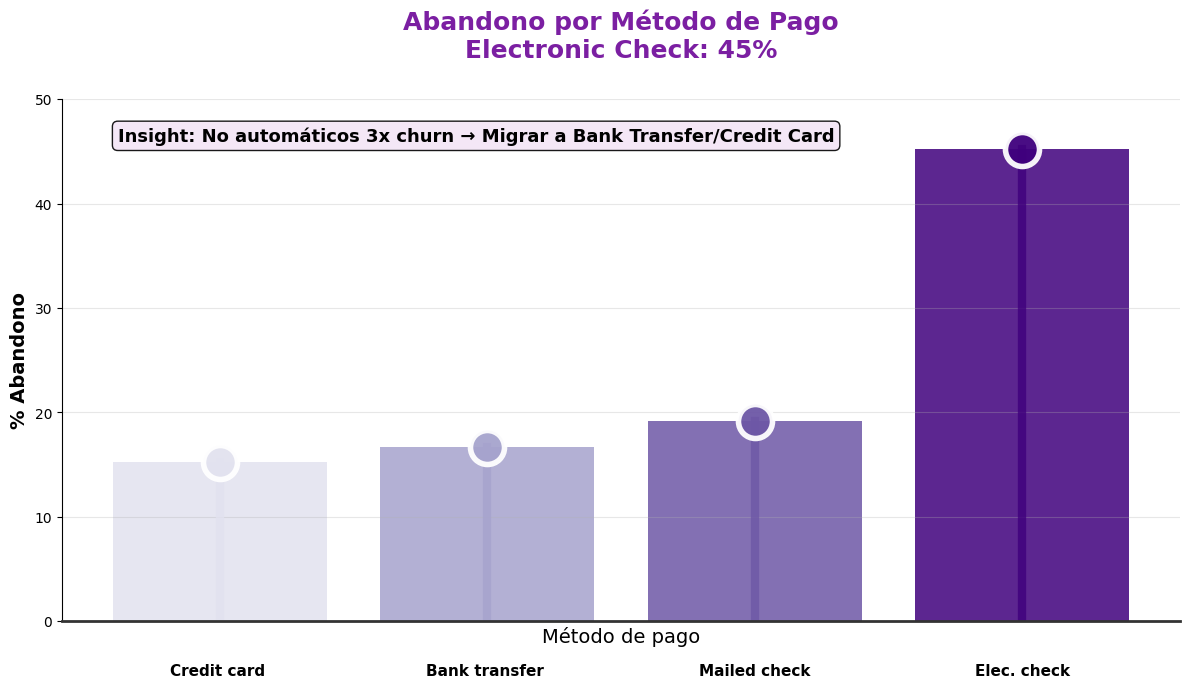

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Ordena por tasa
metodo_sorted = metodo_pago_churn.sort_values('tasa_abandono', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

colors = plt.cm.Purples(np.linspace(0.2, 1, 4))
x_pos = np.arange(len(metodo_sorted))

bars = ax.bar(x_pos, metodo_sorted['tasa_abandono'], color=colors, alpha=0.85)

# Lollipop
for i, v in enumerate(metodo_sorted['tasa_abandono']):
    ax.plot([i, i], [0, v], color=colors[i], linewidth=6, alpha=0.8)
    ax.scatter(i, v, s=600, color=colors[i], alpha=0.95, edgecolors='white', linewidth=4, zorder=5)

# % labels
for i, v in enumerate(metodo_sorted['tasa_abandono']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13, color='white')

# **XTICKS desde COLUMNA metodo_pago** (no index)
for i, label_full in enumerate(metodo_sorted['metodo_pago']):  # ¡COLumna!
    label_short = label_full.replace('(automatic)', '').replace('Electronic', 'Elec.')
    ax.text(i, -4, label_short, ha='center', va='top', fontweight='bold', fontsize=11)

ax.set_ylim(0, 50)
ax.set_title('Abandono por Método de Pago\nElectronic Check: 45%', fontsize=18, fontweight='bold', pad=30, color='#7B1FA2')
ax.text(0.05, 0.92, 'Insight: No automáticos 3x churn → Migrar a Bank Transfer/Credit Card',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#F3E5F5', alpha=0.9))
ax.set_ylabel('% Abandono', fontsize=14, fontweight='bold')
ax.set_xlabel('Método de pago', fontsize=14)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('metodo_final.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [37]:
''' Análisis comparativo N°5: Perfil familiar vs Abandono. Hipótesis:Los clientes sin pareja ni dependientes
podrían tener mayor probabilidad de abandono, ya que tienen menor compromiso con el servicio.'''

# Primero combinamos las tres variables para formar un perfil familiar.

df_final['perfil_familiar'] = (
    df_final['adulto_mayor'].astype(str) + '_' +
    df_final['pareja'].astype(str) + '_' +
    df_final['dependientes'].astype(str)
)

In [38]:
# Los valores de perfil_familiar son boleanos, lo que puede complicar su interpretación, vamos a corregir eso:
def clasificar_perfil(row):

    if row['adulto_mayor'] == 1 and row['pareja'] == 0 and row['dependientes'] == 0:
        return 'Adulto mayor viviendo solo'

    elif row['pareja'] == 1 and row['dependientes'] == 1:
        return 'Pareja con dependientes'

    elif row['pareja'] == 1 and row['dependientes'] == 0:
        return 'Pareja sin dependientes'

    elif row['pareja'] == 0 and row['dependientes'] == 1:
        return 'Cliente con dependientes'

    elif row['pareja'] == 0 and row['dependientes'] == 0:
        return 'Cliente viviendo solo'

    else:
        return 'Otro perfil'

In [39]:
df_final['perfil_familiar'] = df_final.apply(clasificar_perfil, axis=1)

In [40]:
# Ahora si podemos crear el df para el análisis

# Podemos observar que muchas veces el grupo 0_0_0 (vive solo) muestra el churn más alto.

perfil_churn = pd.crosstab(
    df_final['perfil_familiar'],
    df_final['abandono'],
    normalize='index'
) * 100

perfil_churn['tasa_abandono'] = perfil_churn['Yes']

perfil_churn = perfil_churn.rename(columns={
    'No': 'permanece',
    'Yes': 'abandona'
})


perfil_style = perfil_churn.style \
       .format({'permanece': '{:,.1f}', 'abandona': '{:,.1f}', 'tasa_abandono': '{:.1f}%'}) \
       .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['tasa_abandono'], color='#FFCDD2')

perfil_style

abandono,permanece,abandona,tasa_abandono
perfil_familiar,,,
Adulto mayor viviendo solo,50.8,49.2,49.2%
Cliente con dependientes,78.6,21.4,21.4%
Cliente viviendo solo,68.8,31.2,31.2%
Pareja con dependientes,85.7,14.3,14.3%
Pareja sin dependientes,74.6,25.4,25.4%


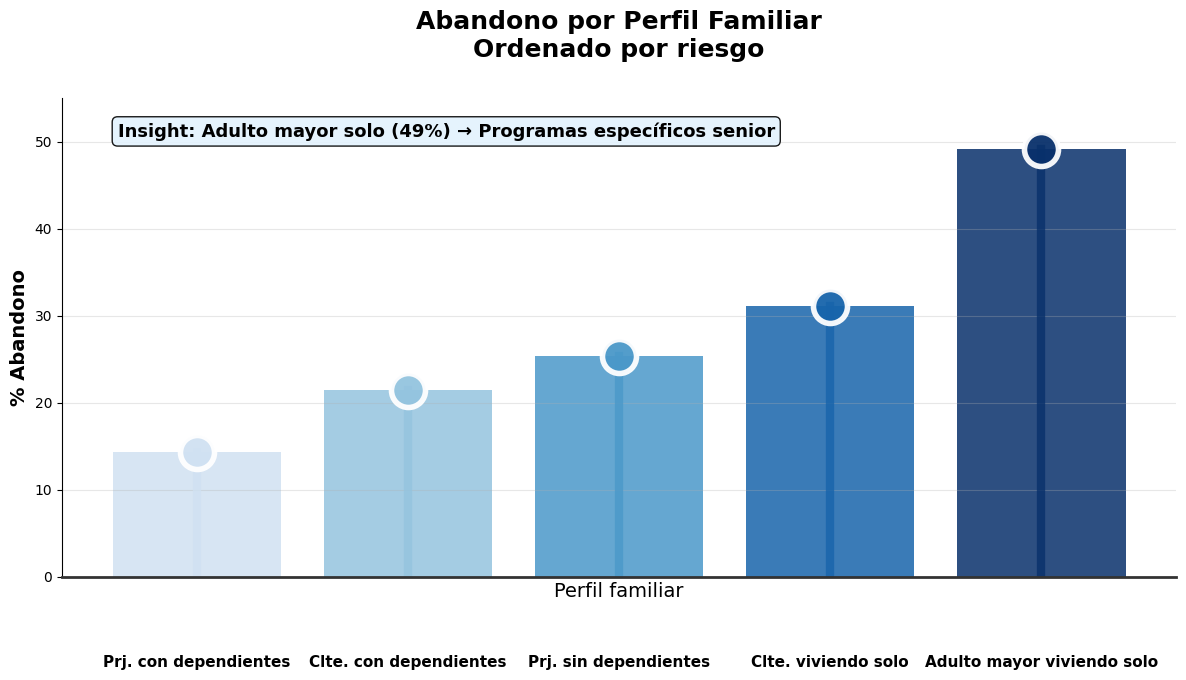

In [41]:
import matplotlib.pyplot as plt
import numpy as np


perfil_churn_sorted = perfil_churn.sort_values('tasa_abandono', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

colors = plt.cm.Blues(np.linspace(0.2, 1, 5))
x_pos = np.arange(len(perfil_churn_sorted))


bars = ax.bar(x_pos, perfil_churn_sorted['tasa_abandono'], color=colors, alpha=0.85)
for i, v in enumerate(perfil_churn_sorted['tasa_abandono']):
    ax.plot([i, i], [0, v], color=colors[i], linewidth=6, alpha=0.8)
    ax.scatter(i, v, s=600, color=colors[i], alpha=0.95,
               edgecolors='white', linewidth=4, zorder=5)


for i, v in enumerate(perfil_churn_sorted['tasa_abandono']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12, color='white')


for i, label_full in enumerate(perfil_churn_sorted['perfil_familiar']):
    label_short = label_full.replace('Cliente ', 'Clte. ').replace('Pareja ', 'Prj. ')
    ax.text(i, -9, label_short, ha='center', va='top', fontweight='bold', fontsize=11)

ax.set_ylim(0, 55)
ax.set_title('Abandono por Perfil Familiar\nOrdenado por riesgo', fontsize=18, fontweight='bold', pad=30)
ax.text(0.05, 0.92, 'Insight: Adulto mayor solo (49%) → Programas específicos senior',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.9))
ax.set_ylabel('% Abandono', fontsize=14, fontweight='bold')
ax.set_xlabel('Perfil familiar', fontsize=14)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('perfil_perfecto.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

Los adultos mayores que viven solos tienen la mayor probabilidad de abandonar el servicio.

Posibles razones:

* Dificultad con tecnología
Servicios de telecomunicaciones pueden resultar más complejos.

* Menor dependencia del servicio
Una familia usa más internet, TV, streaming, etc.

* Mayor sensibilidad al precio

* Menor adopción de servicios adicionales

#📄Informe final

In [42]:
factores_abandono = pd.DataFrame({

    'Factor': [
        'Tipo de contrato',
        'Antigüedad cliente',
        'Cargo mensual',
        'Método de pago',
        'Perfil familiar'
    ],

    'Segmento de mayor riesgo': [
        churn_contract['tasa_abandono'].idxmax(),
        tabla_antiguedad['abandona'].idxmax(),
        cargo_churn['tasa_abandono'].idxmax(),
        metodo_pago_churn['tasa_abandono'].idxmax(),
        perfil_churn['tasa_abandono'].idxmax()
    ],

    'Tasa de abandono (%)': [
        churn_contract['tasa_abandono'].max(),
        tabla_antiguedad['abandona'].max(),
        cargo_churn['tasa_abandono'].max(),
        metodo_pago_churn['tasa_abandono'].max(),
        perfil_churn['tasa_abandono'].max()
    ]
})

In [43]:
factores_abandono = factores_abandono.sort_values(
    by='Tasa de abandono (%)',
    ascending=False
)

factores_estilo = factores_abandono.style \
    .hide(axis="index") \
    .format({"Tasa de abandono (%)": "{:.1f}%"}) \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16pt'), ('font-weight', 'bold'),
                  ('color', '#D32F2F'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#E3F2FD'), ('color', '#1976D2'),
                  ('font-weight', 'bold'), ('font-size', '12pt'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11pt'), ('padding', '12px 10px'),
                  ('text-align', 'center'), ('border', '1px solid #E0E0E0')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('font-family', 'Arial')]}
    ]) \
    .highlight_max(subset=['Tasa de abandono (%)'], color='#FFCDD2')

factores_estilo

Factor,Segmento de mayor riesgo,Tasa de abandono (%)
Antigüedad cliente,0-6 meses,53.3%
Perfil familiar,Adulto mayor viviendo solo,49.2%
Método de pago,Electronic check,45.3%
Tipo de contrato,Month-to-month,42.7%
Cargo mensual,Alto,37.5%


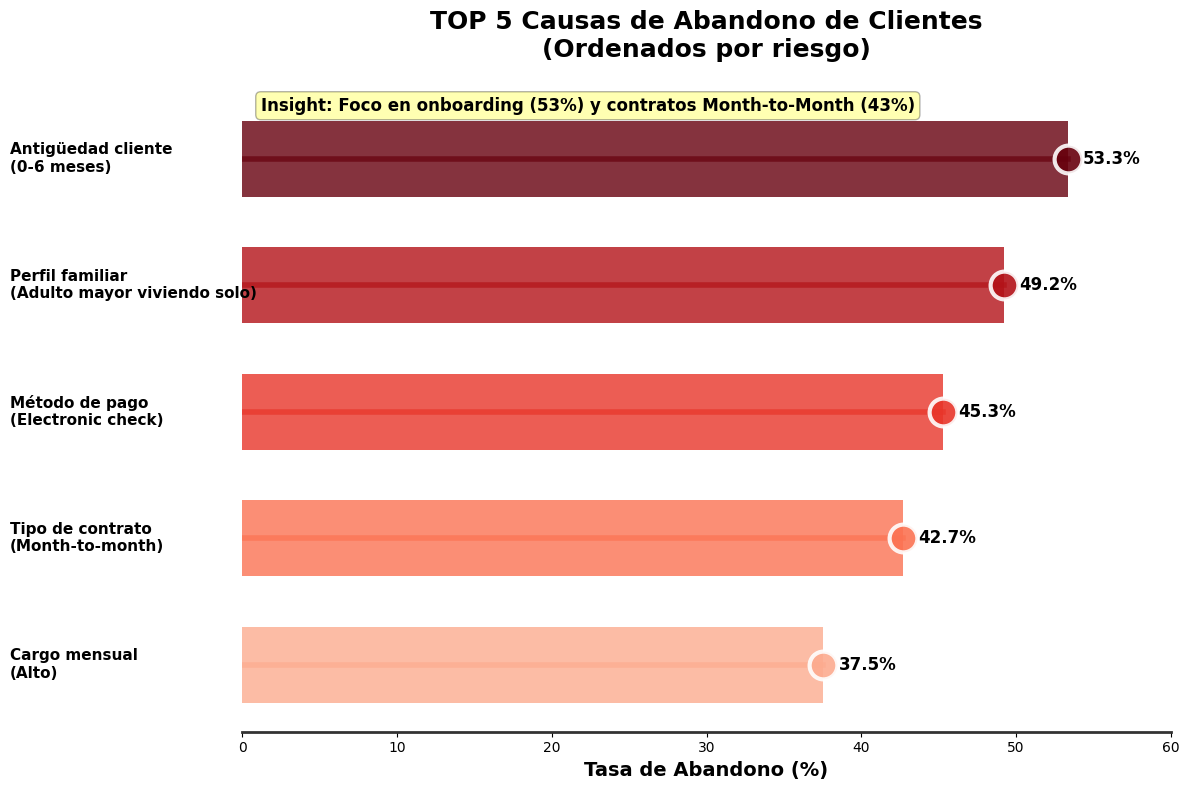

In [44]:
import matplotlib.pyplot as plt
import numpy as np

df_viz = factores_abandono.sort_values('Tasa de abandono (%)', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_viz))

fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

colors = plt.cm.Reds(np.linspace(0.3, 1, len(df_viz)))
bars = ax.barh(y_pos, df_viz['Tasa de abandono (%)'], color=colors, alpha=0.8, height=0.6)

for i, (bar, tasa) in enumerate(zip(bars, df_viz['Tasa de abandono (%)'])):
    ax.plot([0, tasa], [i, i], color=colors[i], linewidth=4, alpha=0.7)
    ax.scatter(tasa, i, s=400, color=colors[i], alpha=0.9, edgecolors='white', linewidth=3, zorder=5)

for i, row in df_viz.iterrows():
    ax.text(row['Tasa de abandono (%)'] + 1, i, f'{row["Tasa de abandono (%)"]:.1f}%',
            va='center', fontweight='bold', fontsize=12)
    ax.text(-15, i, f'{row["Factor"]}\n({row["Segmento de mayor riesgo"]})',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 60)
ax.set_yticks([])
ax.set_xlabel('Tasa de Abandono (%)', fontsize=14, fontweight='bold')
ax.set_title('TOP 5 Causas de Abandono de Clientes\n(Ordenados por riesgo)',
             fontsize=18, fontweight='bold', pad=25)

ax.text(0.02, 0.97, 'Insight: Foco en onboarding (53%) y contratos Month-to-Month (43%)',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# CORREGIDO: spines sin color en linewidth
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('#333')  # Separado

plt.tight_layout()
plt.savefig('drivers_abandono.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Conclusiones y Recomendaciones:**

El análisis exploratorio permitió identificar los principales factores asociados al abandono de clientes (churn) y los segmentos donde este fenómeno se concentra con mayor intensidad.


A partir del DataFrame factores_abandono, se observó que la tasa de abandono no se distribuye de manera uniforme, sino que ciertos segmentos de clientes presentan niveles de riesgo significativamente más altos cuando se combinan con determinados factores operativos o de comportamiento.


Esto sugiere que el churn está influenciado por condiciones específicas del ciclo de vida del cliente y por la interacción entre variables relacionadas con la experiencia del servicio.


La visualización de las causas de abandono permitió identificar patrones claros en los segmentos más vulnerables, lo que facilita priorizar intervenciones estratégicas.


En particular, los segmentos con mayor tasa de abandono representan oportunidades clave para implementar estrategias de retención focalizadas, como programas de fidelización temprana, mejoras en la experiencia del cliente o ajustes en las condiciones del servicio para perfiles específicos.


Desde una perspectiva analítica, este estudio demuestra cómo el uso de técnicas de análisis exploratorio de datos y visualización permite transformar datos operativos en información accionable.


La identificación de drivers de churn proporciona una base sólida para el desarrollo de modelos predictivos de abandono, que podrían integrarse en sistemas de monitoreo o dashboards para anticipar comportamientos de riesgo.


Como pasos futuros, se recomienda complementar este análisis con modelos de machine learning para predicción de churn, evaluación de importancia de variables y análisis longitudinal del comportamiento de los clientes a lo largo del tiempo.


Estas extensiones permitirían mejorar la capacidad predictiva del modelo y apoyar decisiones estratégicas orientadas a reducir la pérdida de clientes y mejorar la retención a largo plazo.

In [45]:
import pandas as pd

def guardar_styler(nombre, styler):
    """
    Guarda un objeto Styler como archivo HTML sin warnings.
    """
    archivo = f"{nombre}.html"
    html = styler.to_html()
    with open(archivo, "w", encoding="utf-8") as f:
        f.write(html)
    print(f"✔ Guardado: {archivo}")


tablas_estilizadas = {
    "contract_style": contract_style,
    "tabla_style": tabla_style,
    "cargo_style": cargo_style,
    "metodo_style": metodo_style,
    "perfil_style": perfil_style,
    "factores_estilo": factores_estilo
}

for nombre, styler in tablas_estilizadas.items():
    guardar_styler(nombre, styler)


✔ Guardado: contract_style.html
✔ Guardado: tabla_style.html
✔ Guardado: cargo_style.html
✔ Guardado: metodo_style.html
✔ Guardado: perfil_style.html
✔ Guardado: factores_estilo.html


In [46]:
html = """
<html>
<head><title>Reporte de Abandono de Clientes</title></head>
<body>
    <h1>Reporte de Abandono de Clientes</h1>
    <h2>Tipo de Contrato</h2>
    {{TABLA_CONTRATO}}
    <h2>Antigüedad del Cliente</h2>
    {{TABLA_ANTIGUEDAD}}
    <h2>Cargo Mensual</h2>
    {{TABLA_CARGO}}
    <h2>Método de Pago</h2>
    {{TABLA_METODO}}
    <h2>Perfil Familiar</h2>
    {{TABLA_PERFIL}}
    <h2>Factores de Abandono</h2>
    {{TABLA_FACTORES}}
</body>
</html>
"""

# Chain the replacements to create a final HTML report
final_html_report = html.replace("{{TABLA_CONTRATO}}", contract_style.to_html())
final_html_report = final_html_report.replace("{{TABLA_ANTIGUEDAD}}", tabla_style.to_html())
final_html_report = final_html_report.replace("{{TABLA_CARGO}}", cargo_style.to_html())
final_html_report = final_html_report.replace("{{TABLA_METODO}}", metodo_style.to_html())
final_html_report = final_html_report.replace("{{TABLA_PERFIL}}", perfil_style.to_html())
final_html_report = final_html_report.replace("{{TABLA_FACTORES}}", factores_estilo.to_html())

# You can now save or display final_html_report
# Example: with open("reporte_final.html", "w") as f:
#              f.write(final_html_report)

In [47]:
!pip freeze > requirements.txt
